Model Performance Metrics:
                     Accuracy  Precision    Recall        F1
Logistic Regression  0.977612   0.967742  0.983607  0.975610
KNN                  0.992537   1.000000  0.983607  0.991736
SVM                  0.977612   0.975410  0.975410  0.975410
Decision Tree        0.996269   0.991870  1.000000  0.995918
Random Forest        0.996269   0.991870  1.000000  0.995918


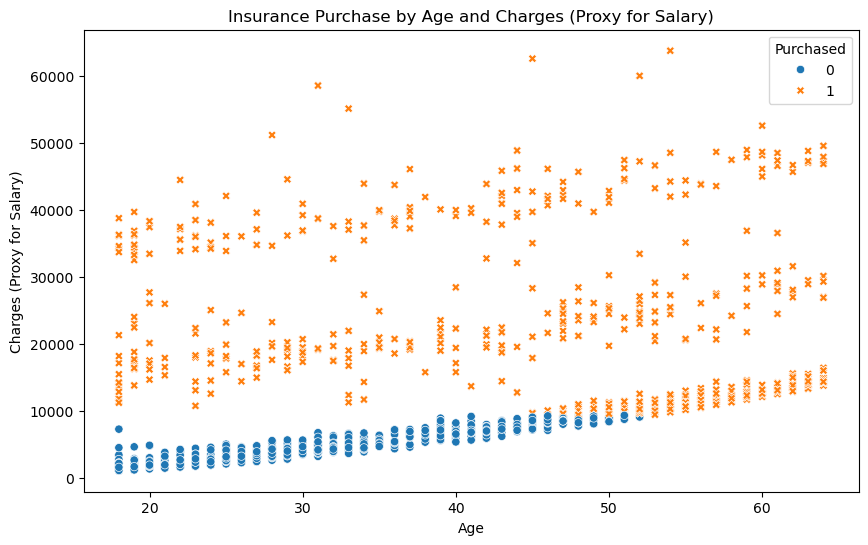


Predictions for Scenarios:
   age    charges Prediction
0   30      87000        Yes
1   40          0         No
2   40     100000        Yes
3   50          0         No
4   18          0         No
5   22     600000        Yes
6   35    2500000        Yes
7   60  100000000        Yes

Feature Importance (Random Forest):
Age: 0.185, Charges (Salary Proxy): 0.815


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('insurance.csv') 


data = data[['age', 'charges']].dropna()
median_charges = data['charges'].median()
data['Purchased'] = (data['charges'] > median_charges).astype(int) 

X = data[['age', 'charges']] 
y = data['Purchased']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


models = {
    'Logistic Regression': LogisticRegression(),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier()
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred)
    }


results_df = pd.DataFrame(results).T
print("Model Performance Metrics:")
print(results_df)


plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='age', y='charges', hue='Purchased', style='Purchased')
plt.title('Insurance Purchase by Age and Charges (Proxy for Salary)')
plt.xlabel('Age')
plt.ylabel('Charges (Proxy for Salary)')
plt.show()


test_scenarios = pd.DataFrame({
    'age': [30, 40, 40, 50, 18, 22, 35, 60],
    'charges': [87000, 0, 100000, 0, 0, 600000, 2500000, 100000000] 
})
test_scaled = scaler.transform(test_scenarios)
best_model = models['Random Forest'] 
predictions = best_model.predict(test_scaled)
test_scenarios['Prediction'] = predictions
print("\nPredictions for Scenarios:")
print(test_scenarios.replace({'Prediction': {0: 'No', 1: 'Yes'}}))


importances = models['Random Forest'].feature_importances_
print("\nFeature Importance (Random Forest):")
print(f"Age: {importances[0]:.3f}, Charges (Salary Proxy): {importances[1]:.3f}")